![Tinder](https://full-stack-assets.s3.eu-west-3.amazonaws.com/M03-EDA/Tinder-Symbole.png)

# Speed Dating with Tinder

## Company's description 📇

<a href="https://tinder.com/" target="_blank">Tinder</a> is an online dating and geosocial networking application. In Tinder, users "swipe right" to like or "swipe left" to dislike other users' profiles, which include their photos, a short bio, and a list of their interests.

Tinder was launched by Sean Rad at a hackathon held at the Hatch Labs incubator in West Hollywood in 2012.

As of 2021, Tinder has recorded more than 65 billion matches worldwide.

# Sommaire

1. Imports et Configuration
2. Préparation et nettoyage des données
3. Questions métier
4. Conclusion

# 1. Imports et Configuration

In [81]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

In [82]:
# import des données avec Pandas
df = pd.read_csv("src/Speed+Dating+Data.csv",encoding='latin1')

In [83]:
# statistiques de base
print("nombre de lignes : {}".format(df.shape[0]))
print()



nombre de lignes : 8378



In [84]:


print("statistiques de base: ")
data_desc = df.describe(include='all')
display(data_desc)
print()



statistiques de base: 


,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
count,8378.000000,8377.000000,8378.000000,8378.000000,8378.000000,8378.000000,8378.000000,8378.000000,6532.000000,8378.000000,...,3974.000000,3974.000000,3974.000000,3974.000000,3974.000000,2016.000000,2016.000000,2016.000000,2016.000000,2016.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,283.675937,8.960248,0.500597,17.327166,1.828837,11.350919,16.872046,9.042731,9.295775,8.927668,...,7.240312,8.093357,8.388777,7.658782,7.391545,6.810020,7.615079,7.932540,7.155258,7.048611
std,158.583367,5.491329,0.500029,10.940735,0.376673,5.995903,4.358458,5.514939,5.650199,5.477009,...,1.576596,1.610309,1.459094,1.744670,1.961417,1.507341,1.504551,1.340868,1.672787,1.717988
min,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,5.000000,1.000000,1.000000,1.000000,...,2.000000,2.000000,3.000000,2.000000,1.000000,2.000000,2.000000,4.000000,1.000000,1.000000
25%,154.000000,4.000000,0.000000,8.000000,2.000000,7.000000,14.000000,4.000000,4.000000,4.000000,...,7.000000,7.000000,8.000000,7.000000,6.000000,6.000000,7.000000,7.000000,6.000000,6.000000
50%,281.000000,8.000000,1.000000,16.000000,2.000000,11.000000,18.000000,8.000000,9.000000,8.000000,...,7.000000,8.000000,8.000000,8.000000,8.000000,7.000000,8.000000,8.000000,7.000000,7.000000
75%,407.000000,13.000000,1.000000,26.000000,2.000000,15.000000,20.000000,13.000000,14.000000,13.000000,...,8.000000,9.000000,9.000000,9.000000,9.000000,8.000000,9.000000,9.000000,8.000000,8.000000


In [85]:
print("pourcentage de valeurs manquantes: ")
display(100*df.isnull().sum()/df.shape[0])




pourcentage de valeurs manquantes: 


iid          0.000000
id           0.011936
gender       0.000000
idg          0.000000
condtn       0.000000
              ...    
attr5_3     75.936978
sinc5_3     75.936978
intel5_3    75.936978
fun5_3      75.936978
amb5_3      75.936978
Length: 195, dtype: float64

In [86]:
print("affichage du dataset: ")
display(df.head())
print()

affichage du dataset: 


,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
0,1,1.0,0,1,1,1,10,7,NaN,4,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
1,1,1.0,0,1,1,1,10,7,NaN,3,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
2,1,1.0,0,1,1,1,10,7,NaN,10,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
3,1,1.0,0,1,1,1,10,7,NaN,5,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
4,1,1.0,0,1,1,1,10,7,NaN,7,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN


In [87]:
print("pourcentage de valeurs manquantes: ")
valeurs_manquantes = 100*df.isnull().sum()/df.shape[0]
colonnes_vides = valeurs_manquantes[valeurs_manquantes >= 50]
print("le nombre de Colonnes avec plus de 50% de valeurs manquantes est de : {}".format(len(colonnes_vides)))


pourcentage de valeurs manquantes: 
le nombre de Colonnes avec plus de 50% de valeurs manquantes est de : 59


# 2. Préparation et nettoyage des données

In [88]:
print(" Je prends le partie de ne pas garder toutes les colonnes qui ont 50% ou plus de valeurs manquantes,\n -> cela concerne avant tout les valeurs collectées le lendemain et 3 à 4 semaines après le speed dating.")
df = df.loc[:, valeurs_manquantes < 50]

 Je prends le partie de ne pas garder toutes les colonnes qui ont 50% ou plus de valeurs manquantes,
 -> cela concerne avant tout les valeurs collectées le lendemain et 3 à 4 semaines après le speed dating.


In [89]:
print("le dataset contient maintenant {} colonnes ".format(df.shape[1]))

le dataset contient maintenant 136 colonnes 


###  Normalisation des données

In [90]:
print("Sur les 21 vagues de rencontres que contient ce dataset, toutes n'ont pas eût la même échelle de mesure pour certaines colonnes.\nLes attributs suivants (Attirant / Sincère / Intelligent / Amusant / Ambitieux / centre dintérêt ) sont généralement mesurés par une répartission total sur 100,\nor les vagues 6 à 9 sont elles mesurées sur 10 pour chaque attribut.")
print('Je vais transformer les vagues 6 à 9 en équivalent de % pour une somme total des attributs égale à 100')

Sur les 21 vagues de rencontres que contient ce dataset, toutes n'ont pas eût la même échelle de mesure pour certaines colonnes.
Les attributs suivants (Attirant / Sincère / Intelligent / Amusant / Ambitieux / centre dintérêt ) sont généralement mesurés par une répartission total sur 100,
or les vagues 6 à 9 sont elles mesurées sur 10 pour chaque attribut.
Je vais transformer les vagues 6 à 9 en équivalent de % pour une somme total des attributs égale à 100


In [91]:
print("normalisation des vagues 6 à 9")
df.loc[df['wave'].isin([6, 7, 8, 9]),['attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1','attr1_2', 'sinc1_2', 'intel1_2', 'fun1_2', 'amb1_2', 'shar1_2', 'attr4_1', 'sinc4_1', 'intel4_1', 'fun4_1', 'amb4_1', 'shar4_1']]

# groupe 1
gr_1= ['attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1']

# création colonne temporaire somme total des valeurs
df.loc[df['wave'].isin([6, 7, 8, 9]), 'tmp_sum_gr1'] = df.loc[df['wave'].isin([6, 7, 8, 9]), gr_1].sum(axis=1)

for col in gr_1:
    df.loc[df['wave'].isin([6, 7, 8, 9]), col] = round((df[col] / df['tmp_sum_gr1']) * 100,2)


# groupe 2
gr_2= ['attr1_2', 'sinc1_2', 'intel1_2', 'fun1_2', 'amb1_2', 'shar1_2']

# création colonne temporaire somme total des valeurs
df.loc[df['wave'].isin([6, 7, 8, 9]), 'tmp_sum_gr2'] = df.loc[df['wave'].isin([6, 7, 8, 9]), gr_2].sum(axis=1)

for col in gr_2:
    df.loc[df['wave'].isin([6, 7, 8, 9]), col] = round((df[col] / df['tmp_sum_gr2']) * 100,2)

# groupe 3
gr_3= ['attr4_1', 'sinc4_1', 'intel4_1', 'fun4_1', 'amb4_1', 'shar4_1']

# création colonne temporaire somme total des valeurs
df.loc[df['wave'].isin([6, 7, 8, 9]), 'tmp_sum_gr3'] = df.loc[df['wave'].isin([6, 7, 8, 9]), gr_3].sum(axis=1)

for col in gr_3:
    df.loc[df['wave'].isin([6, 7, 8, 9]), col] = round((df[col] / df['tmp_sum_gr3']) * 100,2)

normalisation des vagues 6 à 9


### Gestion des valeurs maquantes

In [92]:
print(" je fais le choix de remplacer les valeurs manquantes par la médiane pour rendre le dataset moins sensible aux valeurs extrêmes")

 je fais le choix de remplacer les valeurs manquantes par la médiane pour rendre le dataset moins sensible aux valeurs extrêmes


In [93]:
# je recible les colonnes avec des valeurs manquantes
valeurs_manquantes = 100*df.isnull().sum()/df.shape[0]
colonnes_vides = valeurs_manquantes[valeurs_manquantes > 0]

# pour chaque colonne avec des valeurs manquantes
for index in colonnes_vides.index:
        # Si le type de cette colonne est float
    if df.loc[:,index].dtypes == 'float64' :
            # alors la valeur des lignes vides est remplacée par la médiane
        df[index] = df[index].fillna(df[index].median())


# 3. Questions métier :

# •	Quels sont les traits les moins souhaitables chez un partenaire masculin ? Est-ce différent pour les partenaires féminines ? 

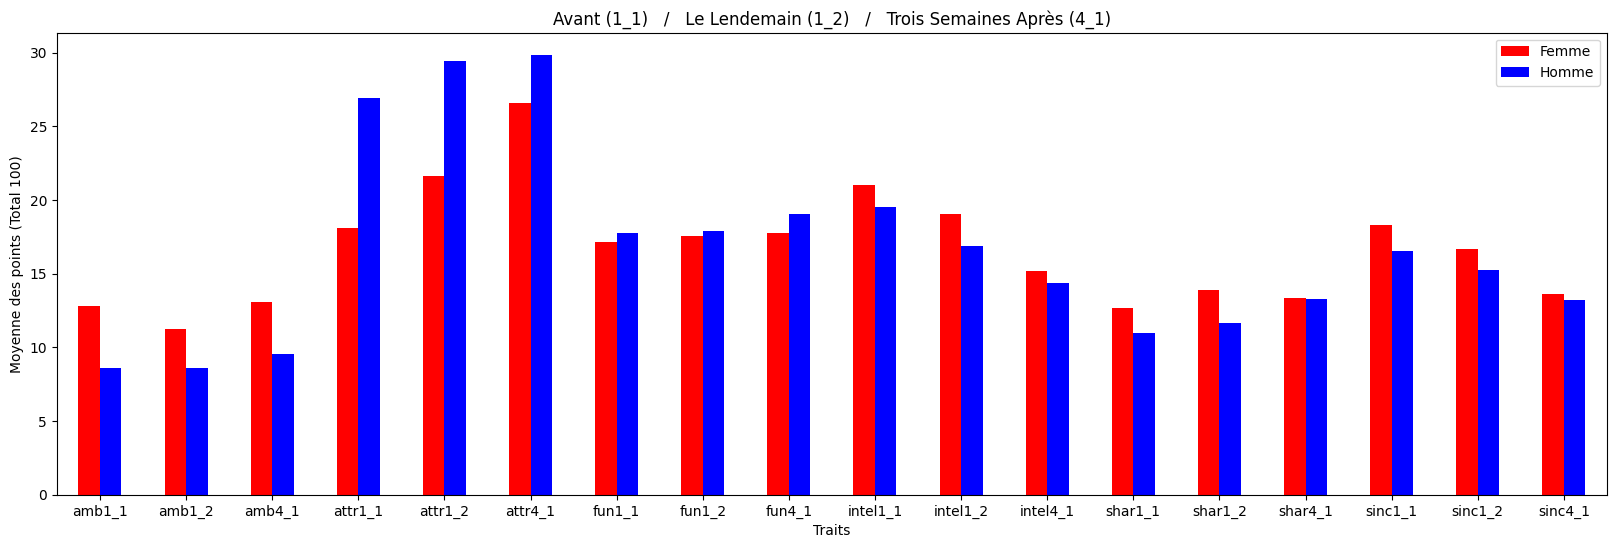

In [94]:
# Calcule la moyenne de chaque trait pour les hommes et les femmes
# 0 = Femme, 1 = Homme
groupe_attributs= ['attr1_2', 'sinc1_2', 'intel1_2', 'fun1_2', 'amb1_2', 'shar1_2','attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1','attr4_1', 'sinc4_1', 'intel4_1', 'fun4_1', 'amb4_1', 'shar4_1']
groupe_attributs.sort()
moyennes_par_genre = df.groupby('gender')[groupe_attributs].mean()

# ajout d'un libellé pour le sous ensemble homme/femme
moyennes_par_genre.index = ['Femme', 'Homme']

# utilisation de la méthode de transposition pour mettre les attributs sur l'axe des abcisses
moyennes_par_genre.T.plot(kind='bar', figsize=(20, 6), color=['red', 'blue'])

# légendes
plt.title("Avant (1_1)   /   Le Lendemain (1_2)   /   Trois Semaines Après (4_1)")
plt.ylabel("Moyenne des points (Total 100)")
plt.xlabel("Traits")
plt.xticks(rotation=0) 
plt.show()

## -> Réponse :  Les femmes et les hommes portent en moyenne moins d'attention à l'ambition.
## ceci même si on compare sur les 3 périodes d'échantillonnage.

# •	Quelle importance les gens attribuent-ils à l'attractivité dans le choix d'un partenaire potentiel, par rapport à son impact réel ? 

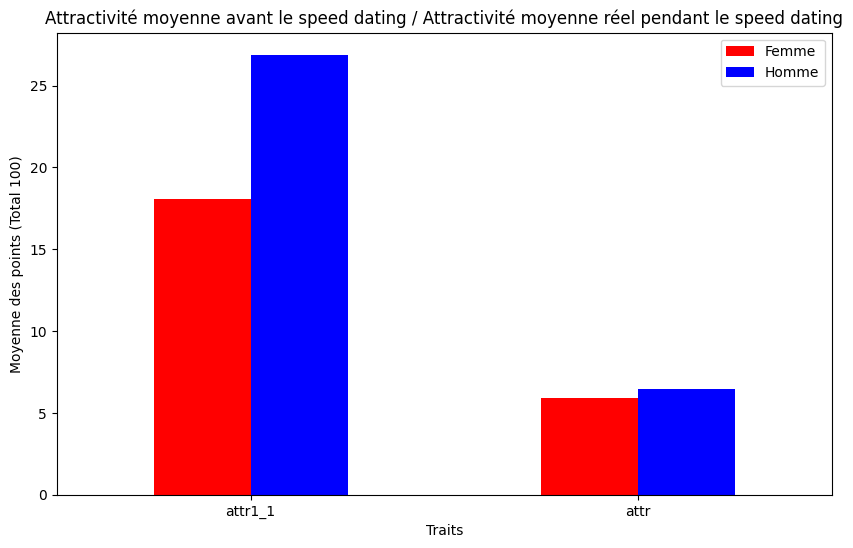

In [95]:
# Calcule la moyenne de chaque trait pour les hommes et les femmes
# 0 = Femme, 1 = Homme
groupe_attributs= ['attr1_1', 'attr']
moyennes_par_genre = df.groupby('gender')[groupe_attributs].mean()

# ajout d'un libellé pour le sous ensemble homme/femme
moyennes_par_genre.index = ['Femme', 'Homme']

# utilisation de la méthode de transposition pour mettre les attributs sur l'axe des abcisses
moyennes_par_genre.T.plot(kind='bar', figsize=(10, 6), color=['red', 'blue'])

# légendes
plt.title("Attractivité moyenne avant le speed dating / Attractivité moyenne réel pendant le speed dating")
plt.ylabel("Moyenne des points (Total 100)")
plt.xlabel("Traits")
plt.xticks(rotation=0) 
plt.show()

## -> réponse : On peut voir que l'attractivité réel chute énormément, d'autres critères prennent plus d'importance face à la réalité. 

# •	Les intérêts communs sont-ils plus importants qu'une origine raciale commune ? 

Influence réelle sur la décision :
samerace    0.023036
int_corr    0.018348
Name: dec, dtype: float64


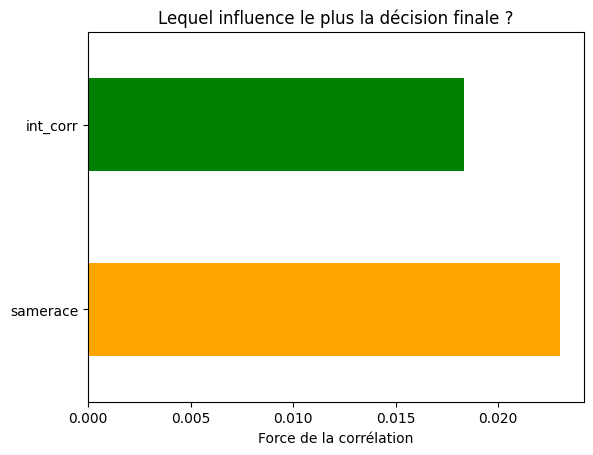

In [96]:
# Calcul de la corrélation avec la décision de se revoir
correlation_decision = df[['dec', 'samerace', 'int_corr']].corr()['dec'].drop('dec')

print("Influence réelle sur la décision :")
print(correlation_decision)

correlation_decision.plot(kind='barh', color=['orange', 'green'])
plt.title("Lequel influence le plus la décision finale ?")
plt.xlabel("Force de la corrélation")
plt.show()

### -> Réponse : les intérêts communs pèsent plus lourd dans la décision de se revoir que l'origine raciale

# •	Les individus peuvent-ils prédire avec précision leur propre valeur perçue sur le marché des rencontres ? 

In [97]:
# regroupement sur les 5 attributs 
notes_des_autres = df.groupby('iid')[['attr_o', 'sinc_o', 'intel_o', 'fun_o', 'amb_o']].mean()
auto_evaluation = df.groupby('iid')[['attr3_1', 'sinc3_1', 'intel3_1', 'fun3_1', 'amb3_1']].first()

#création d'un dataframe avec les deux regrouppements moyens
attribut = pd.DataFrame(data=zip(notes_des_autres.mean(),auto_evaluation.mean()),columns=['notes_des_autres','auto_evaluation'],index=['Attirant','Sincère','Intelligent','Amusant','Ambitieux'])
attribut['auto_vs_autres'] = attribut['auto_evaluation'] - attribut['notes_des_autres']
print(" On se surestime de {} point(s) en moyenne par rapport à ce que les autres nous notent ".format(int(round(attribut['auto_vs_autres'].mean(),1))))

 On se surestime de 1 point(s) en moyenne par rapport à ce que les autres nous notent 


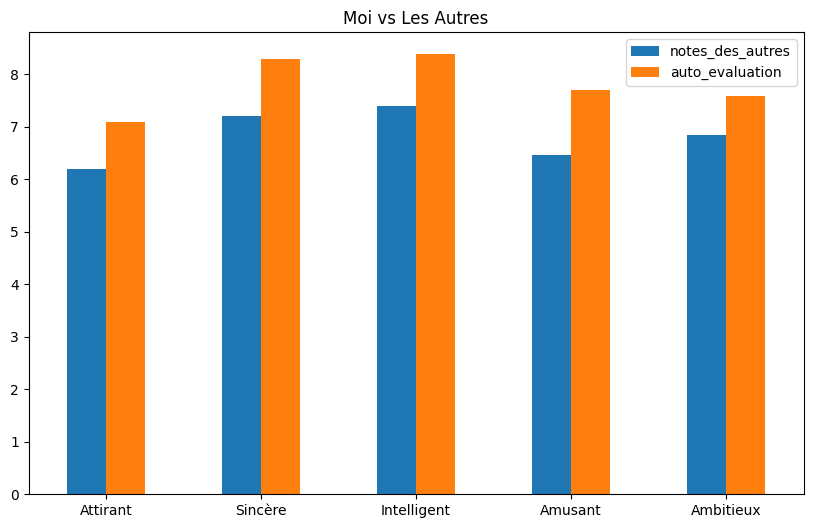

In [98]:
# affichage par attribut des écart pours illustrer  
attribut[['notes_des_autres', 'auto_evaluation']].plot(kind='bar', figsize=(10,6))

plt.title("Moi vs Les Autres")
plt.xticks(rotation=0) 
plt.show()

### -> Réponse : Sur le sujet des attributs, que l'on soit un homme ou une femme, on se surnote d'environ 10% en comparaison des autres.

# •	Pour obtenir un deuxième rendez-vous, vaut-il mieux être le premier ou le dernier rendez-vous rapide de la soirée ? 

In [99]:
print("Pour répondre à cette problématique on va se concentrer sur l'ordre de passage")

# comptabiliser pour chaque ordre de passage par rapport à revoir l'autre
effectif_ordre= df.groupby('order')['dec'].count()

# valeur maximal parmi les ordres
max_eff = effectif_ordre.max()

# affichage de l'indice de fiabilité
print(effectif_ordre/max_eff)
print("\n\n on voit que les effectifs ne sont pas les mêmes selon l'ordre de passage, je choisis arbitrairement d'annalyser uniquement les 14 premiers.\n ( l'indice de fiabilité est de moins de 40% d'écart dans l'effectif de ma population)")


Pour répondre à cette problématique on va se concentrer sur l'ordre de passage
order
1     1.000000
2     1.000000
3     1.000000
4     1.000000
5     1.000000
6     0.981851
7     0.932849
8     0.921960
9     0.911071
10    0.860254
11    0.675136
12    0.675136
13    0.675136
14    0.675136
15    0.606171
16    0.551724
17    0.459165
18    0.459165
19    0.323049
20    0.261343
21    0.156080
22    0.079855
Name: dec, dtype: float64


 on voit que les effectifs ne sont pas les mêmes selon l'ordre de passage, je choisis arbitrairement d'annalyser uniquement les 14 premiers.
 ( l'indice de fiabilité est de moins de 40% d'écart dans l'effectif de ma population)


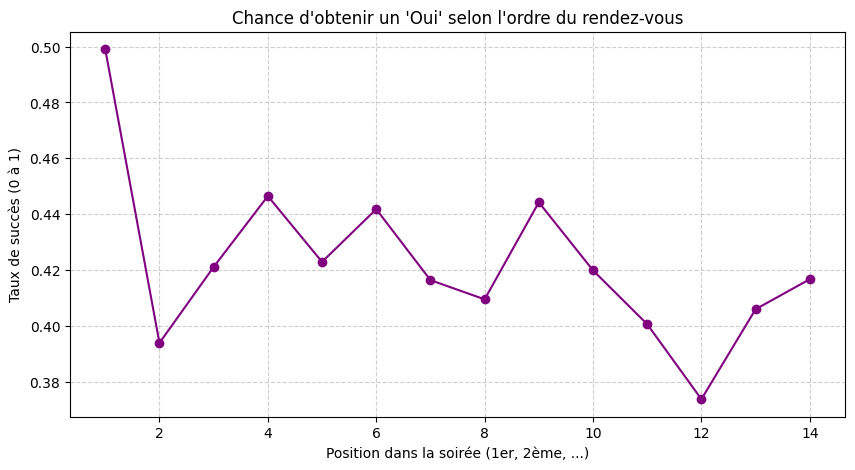

In [100]:
# moyenne par ordre pour ceux qui veulent revoir l'autre
moyen_ordre = df.groupby('order')['dec'].mean()

# graphique pour illustrer
moyen_ordre.iloc[0:14].plot(kind='line', marker='o', figsize=(10, 5), color='purple')

plt.title("Chance d'obtenir un 'Oui' selon l'ordre du rendez-vous")
plt.ylabel("Taux de succès (0 à 1)")
plt.xlabel("Position dans la soirée (1er, 2ème, ...)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### -> Réponse : On voit qu'il y a tout de même un avantage non négligeable à passer en premier, il est possible qu'un facteur de fatigue, ou tout du moins temporel, puisse venir expliquer cette décroissance dans le temps.

# 4. Conclusion
## Cette analyse démontre que l'attractivité, l'humour et le partage d'intérêts sont les principaux moteurs du succès lors d'un rendez-vous, au détriment de critères plus formels comme l'origine raciale.
## On voit que l'on s'autoévalue à la hausse par rapport au regarde que portent les autres sur nous. 
## Il faut également remarquer que si une situation émotionnelle dure trop longtemps, alors l'intérêt diminue, il est préférable de réduire le nombre de rencontre pour chaque soirée.
